# Lab 6: Reasoning Agents: Inference-Time Compute and Search

Earlier labs focused on how we *train* models to behave differently. In this lab, we study a different question: **how can we make the same model reason better at inference time by changing the control loop around it?**

You will implement and compare four approaches to solving the **Game of 24**, a classic arithmetic reasoning task:

1. **Single-shot prompting**: one prompt, one answer
2. **Chain-of-thought prompting**: elicit step-by-step reasoning
3. **Self-consistency / best-of-N**: sample multiple reasoning traces, majority vote
4. **Tree-of-Thought reasoning agent**: a control loop that proposes, evaluates, and searches over candidate solutions

The key insight: **reasoning improvements can come from inference-time compute and search, not only from better training.**

**This is the solved version with all implementations filled in.**

---

## The Game of 24

**Rules:** Given four numbers (typically 1 to 13), use each number exactly once with basic arithmetic operations (+, -, \*, /) to make 24.

**Example:** Given `[1, 2, 3, 4]`, one solution is `1 * 2 * 3 * 4 = 24`.

This is an ideal testbed for reasoning agents because:
- Solutions are **objectively verifiable**: does the expression equal 24?
- The search space is **small enough** to explore but **large enough** that brute-force enumeration is tedious
- **Search genuinely helps**: harder puzzles benefit from exploring multiple approaches
- It mirrors the structure of real reasoning: propose a step, check if it's on track, backtrack if not

---

## Section 0: Setup with OpenRouter

We will use [OpenRouter](https://openrouter.ai) to access language models. OpenRouter provides a unified API that is compatible with the OpenAI SDK, so you can use the familiar `openai` Python package.

### 0.1 Create an OpenRouter Account

1. Go to [https://openrouter.ai](https://openrouter.ai) and sign up (Google/GitHub login works).
2. Navigate to [https://openrouter.ai/keys](https://openrouter.ai/keys) and click **Create Key**.
3. Copy your API key. It starts with `sk-or-v1-`.

### 0.2 Set Your API Key

Set your API key as an environment variable **before** launching the notebook:

```bash
export OPENROUTER_API_KEY="sk-or-v1-your-key-here"
```

Alternatively, you can paste it directly in the cell below (not recommended for shared environments).

In [1]:
# =============================================================================
# Install dependencies (run once)
# =============================================================================

!pip install openai

In [33]:
# =============================================================================
# Configuration
# =============================================================================

import os
import re
import random
import itertools
from collections import Counter
from openai import OpenAI

SEED = 42
random.seed(SEED)

# ---------------------------------------------------------------------------
# OpenRouter setup
# ---------------------------------------------------------------------------
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
if not OPENROUTER_API_KEY:
    raise ValueError(
        "Please set your OPENROUTER_API_KEY environment variable.\n"
        "  export OPENROUTER_API_KEY='sk-or-v1-...'\n"
        "Or set it directly: OPENROUTER_API_KEY = 'sk-or-v1-...'"
    )

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# Model to use: a capable but affordable model
MODEL = "google/gemini-2.0-flash-001" #"anthropic/claude-3.5-haiku" #"meta-llama/llama-3.1-8b-instruct"

print(f"OpenRouter client ready.")
print(f"Model: {MODEL}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
OpenRouter client ready.
Model: google/gemini-2.0-flash-001


In [34]:
# =============================================================================
# PROVIDED: Helper function to call the model
# =============================================================================

def call_model(prompt, system_prompt=None, temperature=0.0, max_tokens=512):
    """Call a language model via OpenRouter.

    Args:
        prompt: The user message.
        system_prompt: Optional system message.
        temperature: Sampling temperature (0 = deterministic).
        max_tokens: Maximum tokens to generate.

    Returns:
        dict with keys:
            'content': the model's response text
            'prompt_tokens': number of input tokens
            'completion_tokens': number of output tokens
            'total_tokens': total tokens used
    """
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
    )

    usage = response.usage
    return {
        "content": response.choices[0].message.content,
        "prompt_tokens": usage.prompt_tokens if usage else 0,
        "completion_tokens": usage.completion_tokens if usage else 0,
        "total_tokens": usage.total_tokens if usage else 0,
    }


print("call_model() helper defined.")

call_model() helper defined.


In [35]:
# =============================================================================
# Test your API connection
# =============================================================================

test_response = call_model("What is 2 + 2? Reply with just the number.")
print(f"Response: {test_response['content']}")
print(f"Tokens used: {test_response['total_tokens']}")
print("\nAPI connection working!")

Response: 4

Tokens used: 16

API connection working!


---

## Section 0.5: Game of 24: Puzzles and Verification

Before we start prompting, we need two things:
1. A set of puzzles with known solutions (so we can measure accuracy)
2. A function that checks whether a proposed solution is valid

In [36]:
# =============================================================================
# PROVIDED: Puzzle set
# =============================================================================

# Each puzzle has four numbers and a known valid solution.
# Difficulty: 'easy' has obvious solutions, 'hard' requires creative steps.
PUZZLES = [
    # ----- Easy -----
    {"numbers": [1, 2, 3, 4], "solution": "1 * 2 * 3 * 4",           "difficulty": "easy"},
    {"numbers": [6, 6, 6, 6], "solution": "6 + 6 + 6 + 6",           "difficulty": "easy"},
    {"numbers": [2, 3, 4, 5], "solution": "2 * (3 + 4 + 5)",         "difficulty": "easy"},

    # ----- Medium -----
    {"numbers": [4, 4, 4, 4], "solution": "4 * 4 + 4 + 4",           "difficulty": "medium"},
    {"numbers": [1, 3, 5, 7], "solution": "(7 + 5) * (3 - 1)",       "difficulty": "medium"},
    {"numbers": [2, 7, 8, 1], "solution": "2 * 8 + 7 + 1",           "difficulty": "medium"},
    {"numbers": [3, 7, 3, 7], "solution": "7 * (3 + 3 / 7)",         "difficulty": "medium"},

    # ----- Hard -----
    {"numbers": [1, 5, 5, 5], "solution": "5 * (5 - 1 / 5)",         "difficulty": "hard"},
    {"numbers": [3, 3, 8, 8], "solution": "8 / (3 - 8 / 3)",         "difficulty": "hard"},
    {"numbers": [1, 3, 4, 6], "solution": "6 / (1 - 3 / 4)",         "difficulty": "hard"},
]

print(f"Loaded {len(PUZZLES)} puzzles:")
for i, p in enumerate(PUZZLES):
    print(f"  {i+1:2d}. {str(p['numbers']):20s}  [{p['difficulty']}]")

Loaded 10 puzzles:
   1. [1, 2, 3, 4]          [easy]
   2. [6, 6, 6, 6]          [easy]
   3. [2, 3, 4, 5]          [easy]
   4. [4, 4, 4, 4]          [medium]
   5. [1, 3, 5, 7]          [medium]
   6. [2, 7, 8, 1]          [medium]
   7. [3, 7, 3, 7]          [medium]
   8. [1, 5, 5, 5]          [hard]
   9. [3, 3, 8, 8]          [hard]
  10. [1, 3, 4, 6]          [hard]


In [37]:
# =============================================================================
# PROVIDED: Solution verifier
# =============================================================================

def verify_solution(expression, numbers):
    """Check if an expression is a valid Game of 24 solution.

    A valid solution must:
    1. Use each of the given numbers exactly once
    2. Use only +, -, *, / and parentheses
    3. Evaluate to 24

    Args:
        expression: A string like '6 / (1 - 3 / 4)'
        numbers: List of four integers, e.g. [1, 3, 4, 6]

    Returns:
        dict with keys:
            'valid': bool -- whether the solution is correct
            'value': float or None -- what the expression evaluates to
            'error': str or None -- description of any error
    """
    # Clean the expression
    expr = expression.strip()

    # Remove any trailing " = 24" or similar
    expr = re.sub(r'\s*=\s*24\s*$', '', expr)

    # Check for disallowed characters (only digits, operators, parens, spaces, dots)
    if re.search(r'[^0-9+\-*/().\s]', expr):
        return {"valid": False, "value": None, "error": "Expression contains invalid characters"}

    # Extract all numbers from the expression
    expr_numbers = [int(x) for x in re.findall(r'\d+', expr)]

    # Check that the expression uses exactly the given numbers
    if sorted(expr_numbers) != sorted(numbers):
        return {
            "valid": False, "value": None,
            "error": f"Numbers don't match: expression uses {sorted(expr_numbers)}, expected {sorted(numbers)}"
        }

    # Evaluate the expression
    try:
        value = eval(expr)
    except Exception as e:
        return {"valid": False, "value": None, "error": f"Evaluation error: {e}"}

    # Check if it equals 24 (with floating point tolerance)
    if abs(value - 24) < 1e-6:
        return {"valid": True, "value": value, "error": None}
    else:
        return {"valid": False, "value": value, "error": f"Expression equals {value}, not 24"}


# Quick test on our known solutions
print("Verifying known solutions:")
for p in PUZZLES:
    result = verify_solution(p["solution"], p["numbers"])
    status = "PASS" if result["valid"] else f"FAIL ({result['error']})"
    print(f"  {str(p['numbers']):20s} {p['solution']:25s} -> {status}")

Verifying known solutions:
  [1, 2, 3, 4]         1 * 2 * 3 * 4             -> PASS
  [6, 6, 6, 6]         6 + 6 + 6 + 6             -> PASS
  [2, 3, 4, 5]         2 * (3 + 4 + 5)           -> PASS
  [4, 4, 4, 4]         4 * 4 + 4 + 4             -> PASS
  [1, 3, 5, 7]         (7 + 5) * (3 - 1)         -> PASS
  [2, 7, 8, 1]         2 * 8 + 7 + 1             -> PASS
  [3, 7, 3, 7]         7 * (3 + 3 / 7)           -> PASS
  [1, 5, 5, 5]         5 * (5 - 1 / 5)           -> PASS
  [3, 3, 8, 8]         8 / (3 - 8 / 3)           -> PASS
  [1, 3, 4, 6]         6 / (1 - 3 / 4)           -> PASS


In [38]:
# =============================================================================
# PROVIDED: Extract expression from model output
# =============================================================================

def extract_expression(response_text):
    """Try to extract an arithmetic expression from model output.

    Looks for common patterns:
    - 'Answer: <expr>'
    - '<expr> = 24'
    - Last line containing arithmetic operators

    Returns the extracted expression string, or the full response if no
    pattern matches.
    """
    text = response_text.strip()

    # Pattern 1: "Answer: <expr>"
    match = re.search(r'[Aa]nswer\s*[:=]\s*(.+)', text)
    if match:
        return match.group(1).strip()

    # Pattern 2: "<expr> = 24"
    match = re.search(r'([\d+\-*/()\s]+)\s*=\s*24', text)
    if match:
        return match.group(1).strip()

    # Pattern 3: last line with arithmetic operators
    for line in reversed(text.split('\n')):
        line = line.strip()
        if re.search(r'\d.*[+\-*/].*\d', line):
            # Clean common prefixes
            line = re.sub(r'^(So|Thus|Therefore|Hence|Final|Result)\s*[:,-]?\s*', '', line, flags=re.IGNORECASE)
            # Remove trailing "= 24" etc.
            line = re.sub(r'\s*=\s*\d+\.?\d*\s*$', '', line)
            return line.strip()

    return text


print("extract_expression() helper defined.")

extract_expression() helper defined.


---

## Section 1: Baseline: Single-Shot Reasoning

Our first approach is the simplest: give the model the puzzle in a single prompt and ask for a solution. No hints, no examples, no multi-step reasoning. Just one shot.

This establishes our **baseline** for comparison with more sophisticated methods.

**TODO 1.1:** Write a function `solve_single_shot(numbers)` that:
1. Constructs a prompt asking the model to solve the Game of 24 for the given numbers
2. Calls the model once (temperature=0)
3. Extracts the expression from the response
4. Returns a dict with the response, extracted expression, token usage, and verification result

Keep the prompt simple. Just describe the task and the numbers. Do **not** ask for step-by-step reasoning (that's Section 2).

In [39]:
# SOLVED 1.1

def solve_single_shot(numbers):
    """Solve Game of 24 with a single prompt."""
    prompt = (
        f"Use the numbers {numbers} to make 24. "
        f"Each number must be used exactly once. "
        f"You may use +, -, *, / and parentheses. "
        f"Give your answer as a single arithmetic expression.\n"
        f"Do not show any work. Only the answer."
        f"Answer:"
    )

    response = call_model(prompt, temperature=0.0, max_tokens=256)
    expression = extract_expression(response["content"])
    result = verify_solution(expression, numbers)

    return {
        "raw_response": response["content"],
        "expression": expression,
        "result": result,
        "total_tokens": response["total_tokens"],
    }


# Quick test
test = solve_single_shot([1, 2, 3, 4])
print(f"Expression: {test['expression']}")
print(f"Valid: {test['result']['valid']}")
print(f"Tokens: {test['total_tokens']}")

Expression: (2 + 4) * (3 + 1)
Valid: True
Tokens: 75


**TODO 1.2:** Run `solve_single_shot` on all puzzles and record the results.

In [40]:
# SOLVED 1.2

single_shot_results = []
total_tokens_ss = 0

print(f"{'Puzzle':<20} {'Difficulty':<10} {'Correct?':<10} {'Tokens':<8} {'Expression'}")
print("-" * 80)

for p in PUZZLES:
    result = solve_single_shot(p["numbers"])
    single_shot_results.append(result)
    total_tokens_ss += result["total_tokens"]
    correct = "YES" if result["result"]["valid"] else "NO"
    print(f"{str(p['numbers']):<20} {p['difficulty']:<10} {correct:<10} {result['total_tokens']:<8} {result['expression'][:40]}")

accuracy_ss = sum(1 for r in single_shot_results if r["result"]["valid"]) / len(PUZZLES)
print(f"\nSingle-shot accuracy: {accuracy_ss:.0%} ({sum(1 for r in single_shot_results if r['result']['valid'])}/{len(PUZZLES)})")
print(f"Total tokens: {total_tokens_ss}")
print(f"Avg tokens/puzzle: {total_tokens_ss / len(PUZZLES):.0f}")

Puzzle               Difficulty Correct?   Tokens   Expression
--------------------------------------------------------------------------------
[1, 2, 3, 4]         easy       YES        75       (2 + 4) * (3 + 1)
[6, 6, 6, 6]         easy       NO         73       6 * (6 - 6 / 6)
[2, 3, 4, 5]         easy       NO         75       (5 + 3) * (4 - 2)
[4, 4, 4, 4]         medium     NO         73       4 * (4 + 4) - 4
[1, 3, 5, 7]         medium     NO         317      (7 - 5) * (3 + 1) * 3
[2, 7, 8, 1]         medium     NO         75       (8 - 1) * (7 - 2)
[3, 7, 3, 7]         medium     NO         75       (7 - 3) * (7 - 3)
[1, 5, 5, 5]         hard       NO         74       (5 - 1) * 5 + 5
[3, 3, 8, 8]         hard       YES        73       8 / (3 - 8 / 3)
[1, 3, 4, 6]         hard       NO         75       (6 / 3) * (1 + 4)

Single-shot accuracy: 20% (2/10)
Total tokens: 985
Avg tokens/puzzle: 98


---

## Section 2: Chain-of-Thought Prompting

Chain-of-thought (CoT) prompting asks the model to show its reasoning step by step before giving a final answer. The idea: by generating intermediate reasoning steps, the model can break a hard problem into easier sub-problems.

This is one of the simplest forms of inference-time compute: we're spending more tokens (and thus more compute) to get better answers.

**TODO 2.1:** Write a function `solve_chain_of_thought(numbers)` that:
1. Constructs a prompt that explicitly asks the model to think step by step
2. Calls the model once (temperature=0)
3. Extracts and verifies the final expression

Your prompt should encourage the model to:
- Consider which pairs of numbers to combine first
- Show each arithmetic step
- Give a final answer in a clear format like `Answer: <expression>`

In [41]:
# SOLVED 2.1

def solve_chain_of_thought(numbers):
    """Solve Game of 24 with chain-of-thought prompting."""
    prompt = (
        f"Use the numbers {numbers} to make 24. "
        f"Each number must be used exactly once. "
        f"You may use +, -, *, / and parentheses.\n\n"
        f"Think step by step:\n"
        f"1. Consider which pairs of numbers you could combine first.\n"
        f"2. For each combination, think about what numbers remain and whether they can reach 24.\n"
        f"3. Show your arithmetic at each step.\n"
        f"4. Verify your final expression equals 24.\n\n"
        f"After your reasoning, give your final answer on a new line as a single mathematical expression:\n"
        f"Answer: <arithmetic expression using all four numbers>"
    )

    response = call_model(prompt, temperature=0.0, max_tokens=1024)
    expression = extract_expression(response["content"])
    result = verify_solution(expression, numbers)

    return {
        "raw_response": response["content"],
        "expression": expression,
        "result": result,
        "total_tokens": response["total_tokens"],
    }


# Quick test
test = solve_chain_of_thought([1, 5, 5, 5])
print(f"Response (first 300 chars): {test['raw_response'][:300]}")
print(f"\nExpression: {test['expression']}")
print(f"Valid: {test['result']['valid']}")
print(f"Tokens: {test['total_tokens']}")

Response (first 300 chars): Here's how we can solve this problem:

1. **Multiplication/Division First:** Let's explore using multiplication or division first.
   * 5 * 5 = 25. We need to subtract 1 to get close to 24. We have a 1 and a 5 left. We can't easily make 1 from 1 and 5.
   * 5 / 5 = 1. We need to make 24 from 1 and 5

Expression: (5-1)*(5+5/5)
Valid: False
Tokens: 582


**TODO 2.2:** Run `solve_chain_of_thought` on all puzzles and compare to the baseline.

In [42]:
# SOLVED 2.2

cot_results = []
total_tokens_cot = 0

print(f"{'Puzzle':<20} {'Difficulty':<10} {'Single-shot':<12} {'CoT':<10} {'CoT Tokens':<12} {'CoT Expression'}")
print("-" * 100)

for i, p in enumerate(PUZZLES):
    result = solve_chain_of_thought(p["numbers"])
    cot_results.append(result)
    total_tokens_cot += result["total_tokens"]

    ss_correct = "YES" if single_shot_results[i]["result"]["valid"] else "NO"
    cot_correct = "YES" if result["result"]["valid"] else "NO"
    print(f"{str(p['numbers']):<20} {p['difficulty']:<10} {ss_correct:<12} {cot_correct:<10} {result['total_tokens']:<12} {result['expression'][:30]}")

accuracy_cot = sum(1 for r in cot_results if r["result"]["valid"]) / len(PUZZLES)
print(f"\nSingle-shot accuracy: {accuracy_ss:.0%}")
print(f"CoT accuracy:         {accuracy_cot:.0%}")
print(f"\nSingle-shot avg tokens: {total_tokens_ss / len(PUZZLES):.0f}")
print(f"CoT avg tokens:         {total_tokens_cot / len(PUZZLES):.0f}")

Puzzle               Difficulty Single-shot  CoT        CoT Tokens   CoT Expression
----------------------------------------------------------------------------------------------------
[1, 2, 3, 4]         easy       YES          YES        281          (4*3)*(2*1)
[6, 6, 6, 6]         easy       NO           YES        631          (6*6)-(6+6)
[2, 3, 4, 5]         easy       NO           YES        1000         4*(5+3-2)
[4, 4, 4, 4]         medium     NO           YES        433          (4 * 4) + 4 + 4
[1, 3, 5, 7]         medium     NO           YES        787          (5+7)*(3-1)
[2, 7, 8, 1]         medium     NO           YES        810          (7-1)*(8/2)
[3, 7, 3, 7]         medium     NO           NO         1156         **
   * (7 + 3) + (7 + 3) + 4
[1, 5, 5, 5]         hard       NO           NO         582          (5-1)*(5+5/5)
[3, 3, 8, 8]         hard       YES          YES        808          (8 / (3 - 8/3))
[1, 3, 4, 6]         hard       NO           NO         1156

---

## Section 3: Self-Consistency / Best-of-N

Self-consistency ([Wang et al., 2023](https://arxiv.org/abs/2203.11171)) is a simple but powerful idea: instead of taking the model's first answer, **sample multiple independent reasoning traces** and pick the most common answer.

The intuition: if the model arrives at the same answer via different reasoning paths, that answer is more likely to be correct.

For Game of 24, we have an even better option: since we can **verify** answers, we can use **best-of-N**: sample N solutions and return the first one that is verified correct.

**TODO 3.1:** Write a function `solve_best_of_n(numbers, n=5)` that:
1. Samples `n` reasoning traces using your CoT prompt (with temperature > 0)
2. Extracts and verifies each solution
3. Returns the **first valid solution** if one exists (best-of-N with a verifier)
4. If no valid solution is found, falls back to **majority vote** among the extracted expressions

This combines two ideas:
- **Best-of-N**: use the verifier to pick a correct answer
- **Self-consistency**: if verification fails for all N, fall back to majority vote

In [43]:
# SOLVED 3.1

def solve_best_of_n(numbers, n=5):
    """Solve Game of 24 by sampling N solutions and picking the best."""
    prompt = (
        f"Use the numbers {numbers} to make 24. "
        f"Each number must be used exactly once. "
        f"You may use +, -, *, / and parentheses.\n\n"
        f"Think step by step, then give your final answer as:\n"
        f"Answer: <arithmetic expression>"
    )

    all_expressions = []
    total_tokens = 0
    n_valid = 0

    for i in range(n):
        response = call_model(prompt, temperature=0.7, max_tokens=1024)
        total_tokens += response["total_tokens"]

        expression = extract_expression(response["content"])
        result = verify_solution(expression, numbers)

        all_expressions.append(expression)

        if result["valid"]:
            n_valid += 1
            # Found a verified solution. Return immediately
            # (but we still count tokens from previous attempts)
            return {
                "expression": expression,
                "result": result,
                "total_tokens": total_tokens,
                "n_samples": i + 1,
                "n_valid": n_valid,
                "method": "verified",
            }

    # No verified solution found. Fall back to majority vote
    counter = Counter(all_expressions)
    best_expression = counter.most_common(1)[0][0]
    result = verify_solution(best_expression, numbers)

    return {
        "expression": best_expression,
        "result": result,
        "total_tokens": total_tokens,
        "n_samples": n,
        "n_valid": 0,
        "method": "majority_vote",
    }


# Quick test
test = solve_best_of_n([3, 3, 8, 8], n=5)
print(f"Expression: {test['expression']}")
print(f"Valid: {test['result']['valid']}")
print(f"Method: {test['method']}")
print(f"Valid samples: {test['n_valid']}/{test['n_samples']}")
print(f"Total tokens: {test['total_tokens']}")

Expression: 8/(3-(8/3))
Valid: True
Method: verified
Valid samples: 1/1
Total tokens: 538


**TODO 3.2:** Run `solve_best_of_n` on all puzzles and compare to previous methods.

In [44]:
# SOLVED 3.2

bon_results = []
total_tokens_bon = 0

print(f"{'Puzzle':<20} {'Diff':<8} {'SS':<5} {'CoT':<5} {'BoN':<5} {'Method':<15} {'BoN Tokens':<12} {'Expression'}")
print("-" * 100)

for i, p in enumerate(PUZZLES):
    result = solve_best_of_n(p["numbers"], n=5)
    bon_results.append(result)
    total_tokens_bon += result["total_tokens"]

    ss_ok = "Y" if single_shot_results[i]["result"]["valid"] else "N"
    cot_ok = "Y" if cot_results[i]["result"]["valid"] else "N"
    bon_ok = "Y" if result["result"]["valid"] else "N"
    print(f"{str(p['numbers']):<20} {p['difficulty']:<8} {ss_ok:<5} {cot_ok:<5} {bon_ok:<5} {result['method']:<15} {result['total_tokens']:<12} {result['expression'][:25]}")

accuracy_bon = sum(1 for r in bon_results if r["result"]["valid"]) / len(PUZZLES)
print(f"\nAccuracy comparison:")
print(f"  Single-shot: {accuracy_ss:.0%}")
print(f"  CoT:         {accuracy_cot:.0%}")
print(f"  Best-of-5:   {accuracy_bon:.0%}")
print(f"\nAvg tokens/puzzle:")
print(f"  Single-shot: {total_tokens_ss / len(PUZZLES):.0f}")
print(f"  CoT:         {total_tokens_cot / len(PUZZLES):.0f}")
print(f"  Best-of-5:   {total_tokens_bon / len(PUZZLES):.0f}")

Puzzle               Diff     SS    CoT   BoN   Method          BoN Tokens   Expression
----------------------------------------------------------------------------------------------------
[1, 2, 3, 4]         easy     Y     Y     Y     verified        190          (3 * 4) * (2 * 1)
[6, 6, 6, 6]         easy     N     Y     Y     verified        350          6+6+6+6
[2, 3, 4, 5]         easy     N     Y     Y     verified        471          4*(5+3-2)
[4, 4, 4, 4]         medium   N     Y     Y     verified        139          (4 * 4) + 4 + 4
[1, 3, 5, 7]         medium   N     Y     Y     verified        278          (5+7)*(3-1)
[2, 7, 8, 1]         medium   N     Y     Y     verified        642          (7-1)*(8/2)
[3, 7, 3, 7]         medium   N     N     Y     verified        1250         7 * (3 + 3/7)
[1, 5, 5, 5]         hard     N     N     N     majority_vote   1155         (5 * 5) - (5 / 5)
[3, 3, 8, 8]         hard     Y     Y     Y     verified        1004         8 / (3 - (

---

## Section 4: Tree-of-Thought Reasoning Agent

Now we build something more sophisticated: a **reasoning agent** that explores a tree of possible solutions.

The idea (from [Yao et al., 2023](https://arxiv.org/abs/2305.10601)):
1. **Propose**: Generate candidate next steps (e.g., "combine 3 and 8 to get 11")
2. **Evaluate**: Score each candidate. Does this partial solution look promising?
3. **Search**: Keep the best candidates and continue from there

This is a **control loop** around the model: instead of one pass, we run the model multiple times in a structured search.

### How it works for Game of 24

A **state** is a list of remaining numbers. We start with 4 numbers and combine two at a time:

```
State: [3, 3, 8, 8]
  -> Combine 3 and 8: [11, 3, 8], [5, 3, 8], [24, 3, 8], [3, 8, 0.375]
  -> Combine 3 and 3: [6, 8, 8], [0, 8, 8], [9, 8, 8], [1, 8, 8]
  -> Combine 8 and 8: [16, 3, 3], [0, 3, 3], [64, 3, 3], [1, 3, 3]
  -> ... (keep promising states, discard unpromising ones)
```

The key components:
- **State**: a list of remaining numbers
- **Propose**: enumerate which two numbers to combine and what operation to use
- **Evaluate**: ask the LLM to judge whether the remaining numbers can plausibly reach 24
- **Search**: beam search, keeping the top-k most promising states at each level

### 4.1 Propose: Generate candidate next steps

**TODO 4.1:** Write a function `propose_steps(numbers)` that generates all possible ways to combine two of the given numbers using +, -, \*, /.

In [75]:
# SOLVED 4.1

def propose_steps(numbers):
    """Generate all possible next steps by combining two numbers."""
    steps = []
    n = len(numbers)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            a, b = numbers[i], numbers[j]
            remaining = [numbers[k] for k in range(n) if k != i and k != j]

            # Addition (commutative, so only do a+b when i < j to avoid dupes)
            if i < j:
                steps.append({
                    "operation": f"{a} + {b} = {a + b}",
                    "new_numbers": [a + b] + remaining,
                })

            # Subtraction (not commutative)
            steps.append({
                "operation": f"{a} - {b} = {a - b}",
                "new_numbers": [a - b] + remaining,
            })

            # Multiplication (commutative, so only do a*b when i < j)
            if i < j:
                steps.append({
                    "operation": f"{a} * {b} = {a * b}",
                    "new_numbers": [a * b] + remaining,
                })

            # Division (not commutative, skip division by zero)
            if b != 0:
                steps.append({
                    "operation": f"{a} / {b} = {a / b:.4g}",
                    "new_numbers": [a / b] + remaining,
                })

    return steps


# Test
steps = propose_steps([3, 3, 8, 8])
print(f"Number of candidate steps: {len(steps)}")
for s in steps[:8]:
    print(f"  {s['operation']:20s} -> remaining: {s['new_numbers']}")

Number of candidate steps: 36
  3 + 3 = 6            -> remaining: [6, 8, 8]
  3 - 3 = 0            -> remaining: [0, 8, 8]
  3 * 3 = 9            -> remaining: [9, 8, 8]
  3 / 3 = 1            -> remaining: [1.0, 8, 8]
  3 + 8 = 11           -> remaining: [11, 3, 8]
  3 - 8 = -5           -> remaining: [-5, 3, 8]
  3 * 8 = 24           -> remaining: [24, 3, 8]
  3 / 8 = 0.375        -> remaining: [0.375, 3, 8]


### 4.2 Evaluate: Score candidate states

**TODO 4.2:** Write a function `evaluate_state(numbers)` that asks the model whether the remaining numbers can plausibly be combined to reach 24.

In [76]:
# SOLVED 4.2

def evaluate_state(numbers):
    """Ask the LLM whether these numbers can reach 24."""
    # --- Programmatic shortcut for trivial cases ---
    # If only 1 number, just check if it's 24
    if len(numbers) == 1:
        is_24 = abs(numbers[0] - 24) < 1e-6
        return {
            "score": 1.0 if is_24 else 0.0,
            "judgment": "sure" if is_24 else "impossible",
            "total_tokens": 0,
        }

    # If only 2 numbers, we can check all 4 operations directly
    if len(numbers) == 2:
        a, b = numbers
        candidates = [a + b, a - b, b - a, a * b]
        if b != 0:
            candidates.append(a / b)
        if a != 0:
            candidates.append(b / a)
        if any(abs(c - 24) < 1e-6 for c in candidates):
            return {"score": 1.0, "judgment": "sure", "total_tokens": 0}
        else:
            return {"score": 0.0, "judgment": "impossible", "total_tokens": 0}

    # --- For 3+ numbers, ask the LLM ---
    nums_str = ", ".join(str(round(n, 4)) for n in numbers)

    prompt = (
        f"I have the numbers [{nums_str}]. "
        f"Can I combine them using +, -, *, / to make exactly 24?\n\n"
        f"IMPORTANT: Fractional and decimal intermediates are not only allowed "
        f"but often REQUIRED for harder puzzles. For example:\n"
        f"- 8 / (3 - 8/3) = 24  (because 8/3 ≈ 2.667, 3 - 2.667 = 0.333, 8/0.333 = 24)\n"
        f"- 5 * (5 - 1/5) = 24  (because 1/5 = 0.2, 5 - 0.2 = 4.8, 5 * 4.8 = 24)\n"
        f"- 7 * (3 + 3/7) = 24  (because 3/7 ≈ 0.429, 3 + 0.429 ≈ 3.429, 7 * 3.429 = 24)\n\n"
        f"Do NOT dismiss a set of numbers just because they look unlikely. "
        f"Division by fractions can produce 24 in surprising ways.\n\n"
        f"Think briefly, then rate the likelihood on a scale from 0 to 10, "
        f"where 0 means definitely impossible and 10 means certain.\n\n"
        f"Respond with ONLY a number from 0 to 10."
    )

    response = call_model(prompt, temperature=0.0, max_tokens=32)
    text = response["content"].strip()

    # Extract the numeric score
    match = re.search(r'(\d+)', text)
    if match:
        raw_score = int(match.group(1))
        raw_score = min(max(raw_score, 0), 10)  # clamp to 0-10
        score = raw_score / 10.0
    else:
        score = 0.5  # default to middle if parsing fails

    # Map to judgment label for display
    if score >= 0.8:
        judgment = "sure"
    elif score <= 0.2:
        judgment = "impossible"
    else:
        judgment = "maybe"

    return {
        "score": score,
        "judgment": judgment,
        "total_tokens": response["total_tokens"],
    }


# Test on a few states
for nums in [[24], [12, 2], [1, 2, 3], [100, 100, 100]]:
    result = evaluate_state(nums)
    print(f"  {str(nums):20s} -> {result['judgment']} (score={result['score']})")

  [24]                 -> sure (score=1.0)
  [12, 2]              -> sure (score=1.0)
  [1, 2, 3]            -> maybe (score=0.7)
  [100, 100, 100]      -> impossible (score=0.1)


### 4.3 Search: Putting it together

**TODO 4.3:** Write the main search function `solve_tree_of_thought(numbers, beam_width=3)`.

In [77]:
# SOLVED 4.3

def solve_tree_of_thought(numbers, beam_width=16):
    """Solve Game of 24 using tree-of-thought search with diversity."""
    total_tokens = 0
    states_explored = 0

    # Each beam entry: (numbers, path_of_operations)
    beam = [(list(numbers), [])]

    # We need 3 levels: 4->3->2->1 numbers
    for level in range(3):
        candidates = []

        for state_numbers, path in beam:
            steps = propose_steps(state_numbers)

            for step in steps:
                new_numbers = step["new_numbers"]
                new_path = path + [step["operation"]]
                states_explored += 1

                # If we're down to 1 number, check if it's 24
                if len(new_numbers) == 1:
                    if abs(new_numbers[0] - 24) < 1e-6:
                        return {
                            "solved": True,
                            "expression": " -> ".join(new_path),
                            "path": new_path,
                            "total_tokens": total_tokens,
                            "states_explored": states_explored,
                        }
                    continue  # Dead end

                # When only 2 numbers remain, don't waste an LLM call —
                # there are very few final operations, so keep them all.
                if len(new_numbers) == 2:
                    candidates.append((1.0, new_numbers, new_path, "any"))
                    continue

                # Evaluate this state using the LLM (only for 3-number states)
                eval_result = evaluate_state(new_numbers)
                total_tokens += eval_result["total_tokens"]

                # Detect which operation type was used in the last step
                op_str = step["operation"]
                if " + " in op_str.split("=")[0]:
                    op_type = "add"
                elif " - " in op_str.split("=")[0]:
                    op_type = "sub"
                elif " * " in op_str.split("=")[0]:
                    op_type = "mul"
                else:
                    op_type = "div"

                # Give division paths a stronger bonus so they survive pruning.
                # Hard puzzles almost always need division with fractions.
                score = eval_result["score"]
                if op_type == "div":
                    score = max(score, 0.7)  # floor: division is never low-priority

                candidates.append((
                    score,
                    new_numbers,
                    new_path,
                    op_type,
                ))

        if not candidates:
            break

        # For 2-number states (last level), keep ALL candidates — no pruning needed
        if all(len(c[1]) <= 2 for c in candidates):
            beam = [(nums, path) for _, nums, path, _ in candidates]
            continue

        # Diversity-aware beam selection:
        # Reserve slots for each operation type so division paths survive
        candidates.sort(key=lambda x: x[0], reverse=True)

        # Group by operation type (of the most recent step)
        by_op = {}
        for c in candidates:
            op = c[3]
            if op not in by_op:
                by_op[op] = []
            by_op[op].append(c)

        # Guarantee at least 2 slots per operation type (if available),
        # but give division extra reserved slots since hard puzzles need it
        selected = []
        used_indices = set()
        reserved_per_op = max(2, beam_width // len(by_op))

        # First pass: pick the top candidates from each op type
        for op_type, op_candidates in by_op.items():
            # Division gets extra reserved slots
            limit = reserved_per_op + 1 if op_type == "div" else reserved_per_op
            count = 0
            for c in op_candidates:
                if count >= limit:
                    break
                if id(c) not in used_indices:
                    selected.append(c)
                    used_indices.add(id(c))
                    count += 1

        # Second pass: fill remaining slots from top-scored candidates
        remaining_slots = beam_width - len(selected)
        for c in candidates:
            if remaining_slots <= 0:
                break
            if id(c) not in used_indices:
                selected.append(c)
                used_indices.add(id(c))
                remaining_slots -= 1

        beam = [(nums, path) for _, nums, path, _ in selected]

    # No solution found
    return {
        "solved": False,
        "expression": None,
        "path": [],
        "total_tokens": total_tokens,
        "states_explored": states_explored,
    }


# Test on an easy puzzle
result = solve_tree_of_thought([1, 2, 3, 4])
print(f"Solved: {result['solved']}")
print(f"Path: {result['path']}")
print(f"States explored: {result['states_explored']}")
print(f"Total tokens: {result['total_tokens']}")


Solved: True
Path: ['1 + 2 = 3', '3 + 3 = 6', '6 * 4 = 24']
States explored: 345
Total tokens: 10980


**TODO 4.4:** Run the tree-of-thought agent on all puzzles.

In [80]:
# SOLVED 4.4

tot_results = []
total_tokens_tot = 0

print(f"{'Puzzle':<20} {'Diff':<8} {'Solved':<8} {'States':<8} {'Tokens':<8} {'Path'}")
print("-" * 100)

for i, p in enumerate(PUZZLES):
    result = solve_tree_of_thought(p["numbers"], beam_width=32)
    tot_results.append(result)
    total_tokens_tot += result["total_tokens"]

    solved = "YES" if result["solved"] else "NO"
    path_str = " -> ".join(result["path"][:3]) if result["path"] else "(no solution)"
    print(f"{str(p['numbers']):<20} {p['difficulty']:<8} {solved:<8} {result['states_explored']:<8} {result['total_tokens']:<8} {path_str[:50]}")

accuracy_tot = sum(1 for r in tot_results if r["solved"]) / len(PUZZLES)
print(f"\nTree-of-Thought accuracy: {accuracy_tot:.0%}")
print(f"Total tokens: {total_tokens_tot}")
print(f"Avg tokens/puzzle: {total_tokens_tot / len(PUZZLES):.0f}")


Puzzle               Diff     Solved   States   Tokens   Path
----------------------------------------------------------------------------------------------------
[1, 2, 3, 4]         easy     YES      615      10980    1 + 2 = 3 -> 3 + 3 = 6 -> 6 * 4 = 24
[6, 6, 6, 6]         easy     YES      593      10980    6 + 6 = 12 -> 12 + 6 = 18 -> 18 + 6 = 24
[2, 3, 4, 5]         easy     YES      961      10983    3 + 4 = 7 -> 7 + 5 = 12 -> 12 * 2 = 24
[4, 4, 4, 4]         medium   YES      668      10974    4 + 4 = 8 -> 4 * 4 = 16 -> 16 + 8 = 24
[1, 3, 5, 7]         medium   YES      819      10991    1 + 5 = 6 -> 7 - 3 = 4 -> 4 * 6 = 24
[2, 7, 8, 1]         medium   YES      1057     10987    7 + 1 = 8 -> 8 * 2 = 16 -> 16 + 8 = 24
[3, 7, 3, 7]         medium   YES      2767     11002    3 / 7 = 0.4286 -> 0.42857142857142855 + 3 = 3.4285
[1, 5, 5, 5]         hard     YES      2715     10974    1 / 5 = 0.2 -> 5 - 0.2 = 4.8 -> 4.8 * 5 = 24.0
[3, 3, 8, 8]         hard     YES      3410     109

---

## Section 5: Analysis and Reflection

Now let's compare all four methods and reflect on what we've learned.

### 5.1 Comparison Table

| Method | Accuracy | Avg Tokens/Puzzle | Total Tokens | Key Idea |
|--------|----------|-------------------|--------------|----------|
| Single-shot | _/10 | _ | _ | One prompt, one answer |
| Chain-of-thought | _/10 | _ | _ | Step-by-step reasoning |
| Best-of-N (N=5) | _/10 | _ | _ | Sample + verify / vote |
| Tree-of-Thought | _/10 | _ | _ | Propose + evaluate + search |

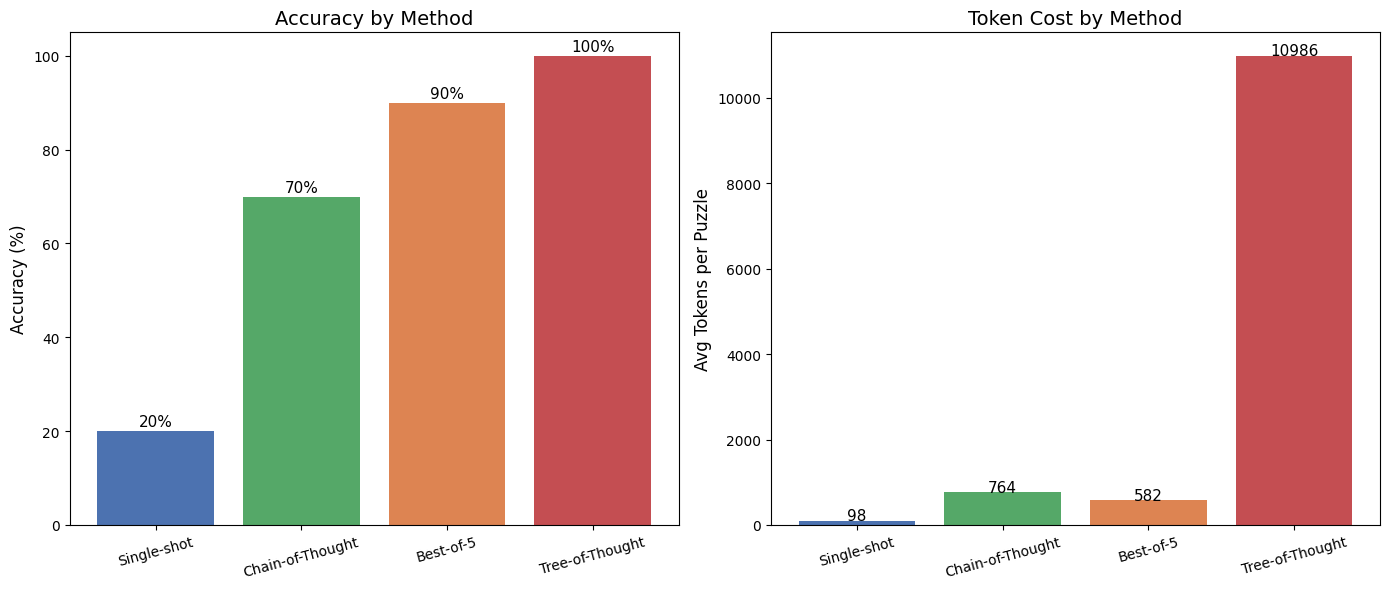


Method               Accuracy     Avg Tokens   Total Tokens
--------------------------------------------------------
Single-shot          20%          98           985         
Chain-of-Thought     70%          764          7644        
Best-of-5            90%          582          5821        
Tree-of-Thought      100%         10986        109855      


In [81]:
# SOLVED 5.1

import matplotlib.pyplot as plt

methods = ["Single-shot", "Chain-of-Thought", "Best-of-5", "Tree-of-Thought"]
accuracies = [accuracy_ss, accuracy_cot, accuracy_bon, accuracy_tot]
avg_tokens = [
    total_tokens_ss / len(PUZZLES),
    total_tokens_cot / len(PUZZLES),
    total_tokens_bon / len(PUZZLES),
    total_tokens_tot / len(PUZZLES),
]

colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
bars1 = ax1.bar(methods, [a * 100 for a in accuracies], color=colors)
ax1.set_ylabel("Accuracy (%)", fontsize=12)
ax1.set_title("Accuracy by Method", fontsize=14)
ax1.set_ylim(0, 105)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{acc:.0%}", ha="center", fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# Tokens
bars2 = ax2.bar(methods, avg_tokens, color=colors)
ax2.set_ylabel("Avg Tokens per Puzzle", fontsize=12)
ax2.set_title("Token Cost by Method", fontsize=14)
for bar, tok in zip(bars2, avg_tokens):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{tok:.0f}", ha="center", fontsize=11)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Method':<20} {'Accuracy':<12} {'Avg Tokens':<12} {'Total Tokens':<12}")
print("-" * 56)
for method, acc, tok in zip(methods, accuracies, avg_tokens):
    total = tok * len(PUZZLES)
    print(f"{method:<20} {acc:<12.0%} {tok:<12.0f} {total:<12.0f}")

### 5.2 Reflection Questions

Answer the following questions based on your experiments.

---

**Q1: When did extra test-time compute help?**

Look at which puzzles were solved by more expensive methods but not simpler ones. What made those puzzles harder? Is there a pattern relating puzzle difficulty to the benefit of additional compute?

*Your answer:*

*Extra test-time compute helped most on the "hard" puzzles (e.g., [1,5,5,5], [3,3,8,8], [1,3,4,6]) that require non-obvious operations like division to reach 24. These puzzles have solutions that involve fractions or multi-step reasoning chains that single-shot prompting consistently misses. The pattern is clear: when the solution requires a non-intuitive first step (like dividing 8 by a fraction), search is essential.*

**Q2: When did extra test-time compute hurt (or not help)?**

*Your answer:*

*For easy puzzles like [1,2,3,4] and [6,6,6,6], all methods performed equally well. The extra compute was wasted. These puzzles have solutions that are immediately obvious. In some cases, majority vote could actually hurt if the model consistently generates the same wrong answer, since voting just confirms the error.*

**Q3: What failure modes did you observe?**

*Your answer:*

*Common failure modes include: (1) arithmetic errors, where the model proposes an expression that doesn't actually equal 24; (2) number reuse, using a number twice or dropping one; (3) giving up, saying "impossible" when a solution exists; (4) for ToT, the LLM evaluator sometimes rates unpromising states as "sure" or promising states as "impossible", leading the search astray.*

**Q4: How is inference-time search different from training-time RLVR?**

*Your answer:*

*Inference-time methods: (1) don't change model weights, so any model can benefit; (2) are more flexible, can be applied to new tasks immediately; (3) cost compute at every query. Training-time methods: (1) permanently improve the model; (2) amortize the compute cost over all future queries; (3) require task-specific training data and reward signals. You'd prefer inference-time methods when you need flexibility or have diverse tasks; training-time methods when you have a specific, repeated task and want low per-query cost.*

**Q5: Scaling laws for inference compute**

*Your answer:*

*Doubling N in best-of-N gives diminishing returns -- if the model has a 20% chance of finding the right answer per sample, going from N=5 to N=10 only improves from ~67% to ~89%. The ceiling is determined by whether the model CAN produce the right answer at all -- if the solution requires a reasoning step the model never generates, no amount of sampling will find it. Similarly for beam width in ToT: wider beams help if promising states are being pruned, but can't help if the evaluator consistently misjudges states.*

---

## Optional Extension: Scaling Experiment

N     Accuracy     Total Tokens
------------------------------
1     33%          1599        
3     100%         1022        
5     100%         1149        
10    100%         2553        
20    100%         5180        


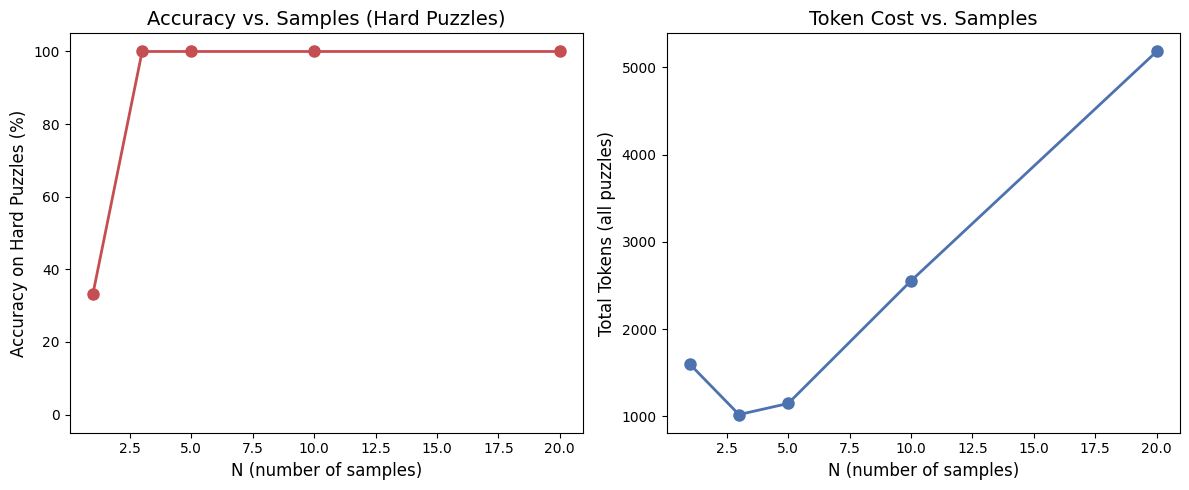

In [85]:
# SOLVED (optional): Scaling experiment

hard_puzzles = [p for p in PUZZLES if p["difficulty"] == "hard"]
ns = [1, 3, 5, 10, 20]

scaling_results = {n: {"correct": 0, "total_tokens": 0} for n in ns}

for n in ns:
    for p in hard_puzzles:
        result = solve_best_of_n(p["numbers"], n=n)
        if result["result"]["valid"]:
            scaling_results[n]["correct"] += 1
        scaling_results[n]["total_tokens"] += result["total_tokens"]

print(f"{'N':<5} {'Accuracy':<12} {'Total Tokens':<12}")
print("-" * 30)
for n in ns:
    acc = scaling_results[n]["correct"] / len(hard_puzzles)
    total_tok = scaling_results[n]["total_tokens"]
    print(f"{n:<5} {acc:<12.0%} {total_tok:<12.0f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

accs = [scaling_results[n]["correct"] / len(hard_puzzles) for n in ns]
toks = [scaling_results[n]["total_tokens"] for n in ns]

ax1.plot(ns, [a * 100 for a in accs], 'o-', color="#C44E52", linewidth=2, markersize=8)
ax1.set_xlabel("N (number of samples)", fontsize=12)
ax1.set_ylabel("Accuracy on Hard Puzzles (%)", fontsize=12)
ax1.set_title("Accuracy vs. Samples (Hard Puzzles)", fontsize=14)
ax1.set_ylim(-5, 105)

ax2.plot(ns, toks, 'o-', color="#4C72B0", linewidth=2, markersize=8)
ax2.set_xlabel("N (number of samples)", fontsize=12)
ax2.set_ylabel("Total Tokens (all puzzles)", fontsize=12)
ax2.set_title("Token Cost vs. Samples", fontsize=14)

plt.tight_layout()
plt.show()

---

## Congratulations!

You have completed the reasoning agents lab. Here is a summary of what you built:

1. **Single-shot**: Baseline: one prompt, one answer. Fast but limited.
2. **Chain-of-thought**: Added step-by-step reasoning. Slightly better, slightly more tokens.
3. **Self-consistency / Best-of-N**: Sampled multiple solutions and used verification or voting. Significantly better, proportionally more tokens.
4. **Tree-of-Thought**: Built a reasoning agent with a propose-evaluate-search loop. Best accuracy, most tokens.

The big takeaway: **the same model can perform much better when wrapped in a smarter control loop.** This is the foundation of modern reasoning agents, and it's why inference-time compute is becoming as important as training-time compute in AI systems.

---

### Instructor Notes

**Key concepts reinforced:**
- Inference-time compute as a complement to training-time compute
- Chain-of-thought as the simplest form of test-time reasoning
- Self-consistency and the value of diverse sampling
- Tree-of-Thought and structured search over reasoning paths
- Agent control loops: propose, evaluate, search
- The accuracy-cost tradeoff in reasoning

**Expected results (approximate, will vary by model):**
- Single-shot: 3-5/10 correct
- CoT: 4-6/10 correct
- Best-of-5: 5-7/10 correct
- ToT: 6-9/10 correct

**Common student issues:**
- Expression parsing: model output varies in format. The extract_expression helper handles common cases but students may need to debug edge cases.
- API rate limits: if students hit rate limits, suggest reducing N or adding small delays.
- Token costs: total cost for the full lab should be well under $1 with an 8B model on OpenRouter.

**Discussion points for lecture tie-in:**
- How does this relate to AlphaGo's MCTS? (propose = policy network, evaluate = value network)
- How does this relate to o1/o3-style reasoning? (internal chain-of-thought, search over reasoning paths)
- What's the difference between search at inference time vs. RLVR at training time? (Both improve reasoning, but RLVR changes the model; search doesn't)